### Tarea 1: Extracción y Procesamiento de Datos (SQL y Python)

#### Tablas y variables de base de datos relacional: 
- **clientes**: id_cliente
- **transacciones**: id_transaccion, id_cliente, id_producto, fecha
- **producto**: id_producto, precio, categoría

#### Supuestos
- En una transacción se pueden adquirir múltiples productos por lo que cada fila de **transacciones** representa un producto dentro de una transacción. Por ende, múltiples filas pueden tener el mismo **id_transaccion**.

#### 1. Consulta SQL 

SELECT  
&emsp; t.id_cliente,   
&emsp; COUNT(DISTINCT t.id_transaccion) AS frecuencia, -- cuenta el número de transacciones por cliente   
&emsp; SUM(p.precio) AS monto_total_gastado, -- suma los montos individuales por cliente  
&emsp; DATEDIFF(CURDATE(), MAX(t.fecha)) AS recencia -- calcula los dias entre la ultima transaccion y el día actual  
FROM transacciones AS t  
JOIN productos AS p ON t.id_producto = p.id_producto  
GROUP BY t.id_cliente

#### 2. Dataset sintético para 1000 clientes

In [87]:
import numpy as np 
import pandas as pd

np.random.seed(220516)

# Cantidad de clientes, posibles categorías favoritas, frecuencia
clientes = 1000
categorias = ["Construcción", "Acabados", "Cocina", "Herramientas", "Pintura"]

# Crear dataset sintético 
df = pd.DataFrame({
    "id_cliente": np.arange(1, clientes + 1),
    "frecuencia": 1+ np.random.poisson(3, clientes),
    "monto_total_gastado": 10 + np.round(np.random.exponential(100, clientes), 2), # Compra mínima de $10
    "recencia": np.random.randint(1, 366, clientes), # Asume clientes transacciones en el último año
    "categoria_fav": np.random.choice(categorias, clientes)}) 

df.head()

,id_cliente,frecuencia,monto_total_gastado,recencia,categoria_fav
0,1,3,137.17,138,Acabados
1,2,2,169.66,200,Acabados
2,3,1,60.97,19,Herramientas
3,4,4,16.38,127,Herramientas
4,5,4,30.80,234,Acabados


### Tarea 2: Modelo Predictivo (Machine Learning Tradicional)
#### 2. Dataset sintético para 1000 clientes



[8573.306012342855, 8098.596925307256, 8051.4497643679115, 7981.316189920996, 8065.536433442152, 8006.671559326871, 8008.524184901562, 8019.5016447406715, 8058.52054075733, 8136.618166732279]


<function matplotlib.pyplot.show(close=None, block=None)>

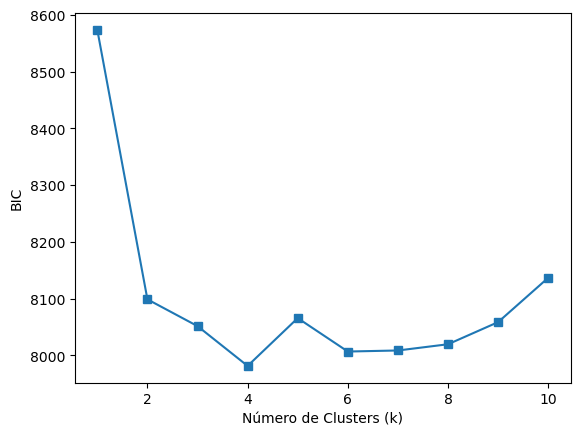

In [90]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

X = df[["frecuencia", "monto_total_gastado", "recencia"]].values

# Normalizar las variables para que estén en la misma escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar el GMM con distintos números de clusters (1 a 10)
bic = []
k_values = range(1, 11) 

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=220516)
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))

print(bic)

# Graficar BIC para los distintos valores de número de clusters
plt. plot(k_values, bic, marker='s')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("BIC")
plt.show

In [92]:
from sklearn.metrics import silhouette_score

# Número óptimo de clusters minimizando BIC
k = k_values[np.argmin(bic)]

# Modelo con número optimo de clusters
gmm = GaussianMixture(n_components=k, random_state=220516)
gmm.fit(X_scaled)

# Asignar el cluster y probabilidad a cada cliente
df["cluster"] = gmm.predict(X_scaled)
df["prob_cluster"] = gmm.predict_proba(X_scaled).max(axis=1)

# Calcular el silhouette score 
silhouette = silhouette_score(X_scaled, df["cluster"])
print(silhouette)

print(df.groupby("cluster")[["frecuencia", "monto_total_gastado", "recencia", "prob_cluster"]].mean())
print(df.groupby("cluster")[["frecuencia", "monto_total_gastado", "recencia", "prob_cluster"]].std())
print(df.groupby("cluster")["id_cliente"].count())


0.14232091271960381
         frecuencia  monto_total_gastado    recencia  prob_cluster
cluster                                                           
0          4.037594           318.720902  184.781955      0.907054
1          3.191489            39.409909  196.018237      0.779753
2          4.118721            95.576438   48.908676      0.780602
3          4.341693           115.088213  241.689655      0.783524
         frecuencia  monto_total_gastado    recencia  prob_cluster
cluster                                                           
0          1.711839           116.071592  102.771690      0.143013
1          1.233348            19.563691   94.489254      0.151450
2          1.805843            54.377951   29.071895      0.148683
3          1.832409            44.974239   72.199154      0.141866
cluster
0    133
1    329
2    219
3    319
Name: id_cliente, dtype: int64
